## Harshal Gode 
## C-C4-48
## ML Lab - 2

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("california_housing.csv")

In [3]:
df.head()

,longitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome,medianHouseValue
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


In [4]:
df.tail()

,longitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome,medianHouseValue
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   longitude         20640 non-null  float64
 1   latitude          20640 non-null  float64
 2   housingMedianAge  20640 non-null  float64
 3   totalRooms        20640 non-null  float64
 4   totalBedrooms     20640 non-null  float64
 5   population        20640 non-null  float64
 6   households        20640 non-null  float64
 7   medianIncome      20640 non-null  float64
 8   medianHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.describe()

,longitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome,medianHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.898014,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.247906,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,295.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
df.shape

(20640, 9)

In [8]:
df.columns

Index(['longitude', 'latitude', 'housingMedianAge', 'totalRooms',
       'totalBedrooms', 'population', 'households', 'medianIncome',
       'medianHouseValue'],
      dtype='object')

In [9]:
df.isnull().sum()

longitude           0
latitude            0
housingMedianAge    0
totalRooms          0
totalBedrooms       0
population          0
households          0
medianIncome        0
medianHouseValue    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates()

,longitude,latitude,housingMedianAge,totalRooms,totalBedrooms,population,households,medianIncome,medianHouseValue
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


<function matplotlib.pyplot.show(close=None, block=None)>

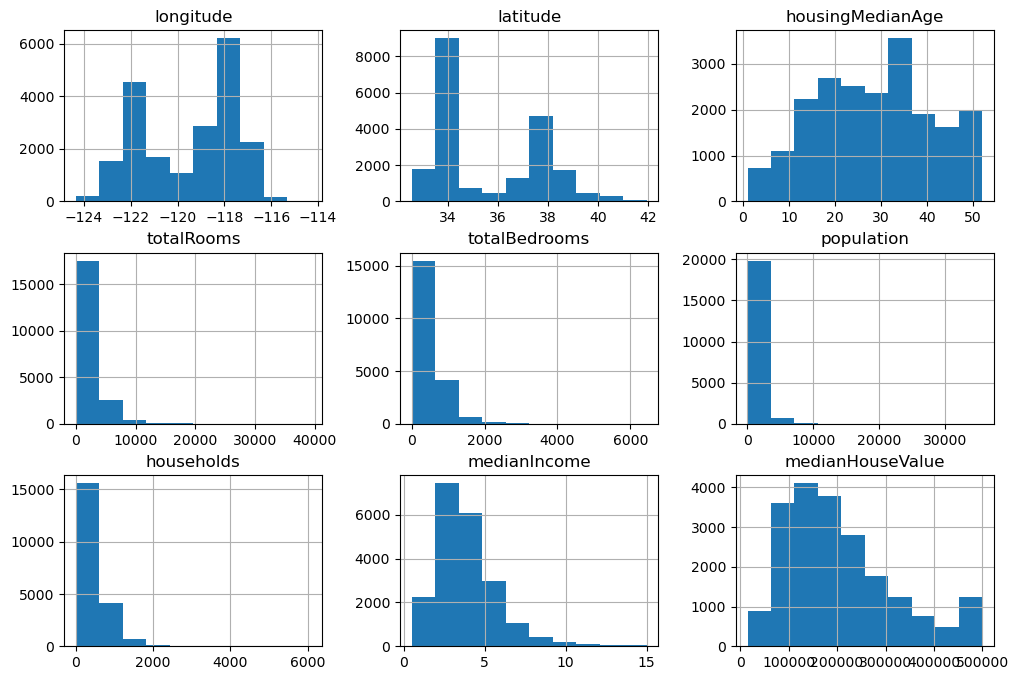

In [12]:
df.hist(figsize=(12,8))
plt.show

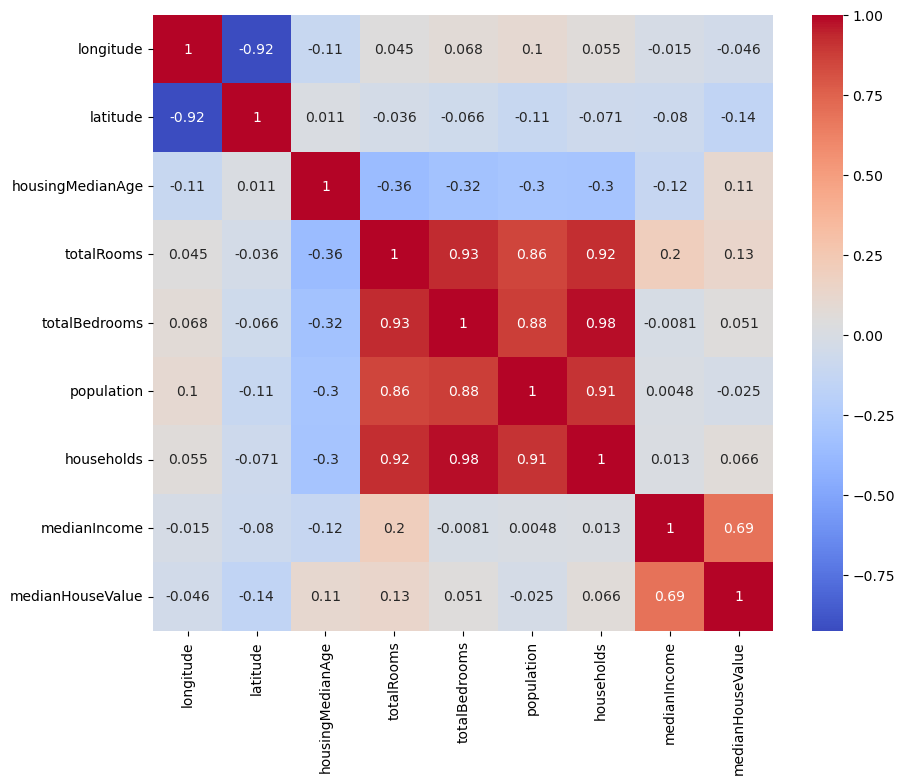

In [13]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

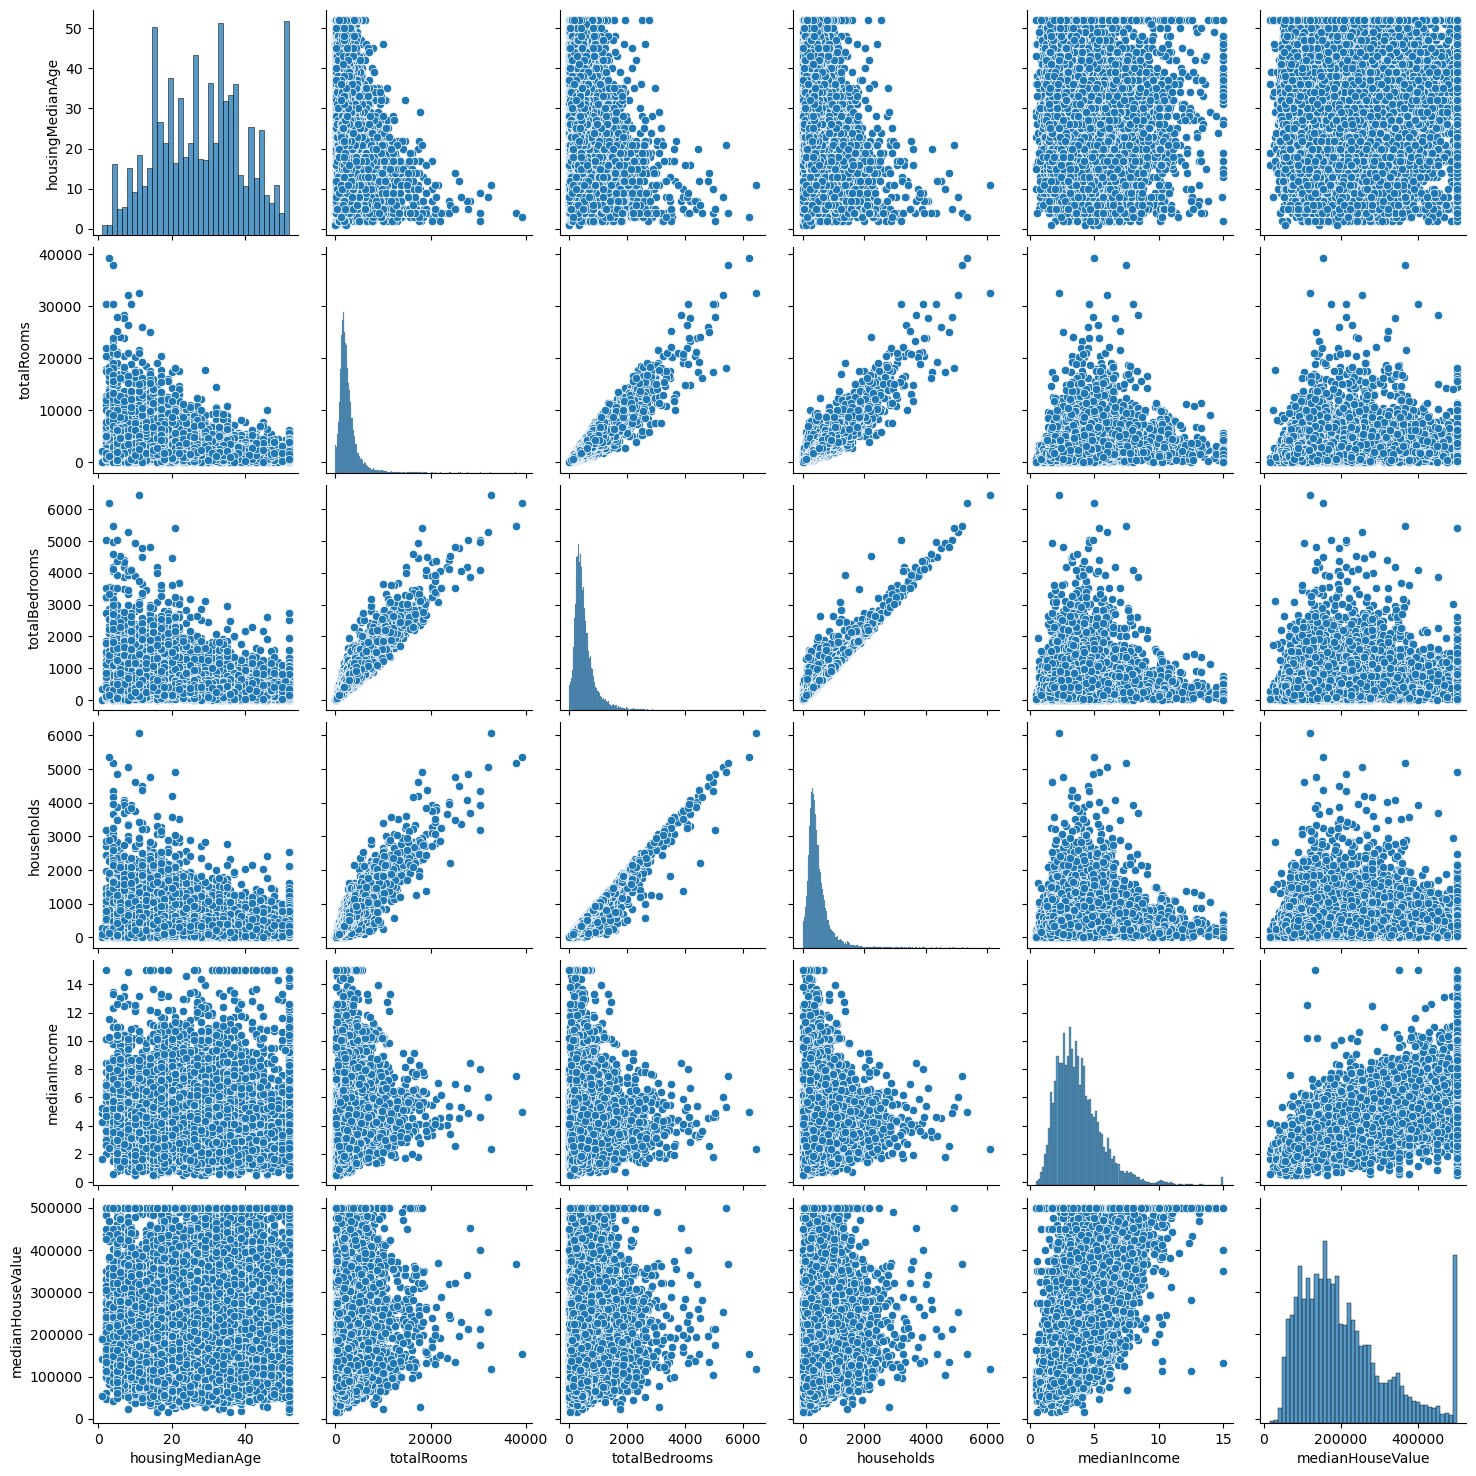

In [14]:
sns.pairplot(df[['housingMedianAge', 'totalRooms',
       'totalBedrooms','households', 'medianIncome',
       'medianHouseValue']])
plt.show()

In [15]:
df.columns

Index(['longitude', 'latitude', 'housingMedianAge', 'totalRooms',
       'totalBedrooms', 'population', 'households', 'medianIncome',
       'medianHouseValue'],
      dtype='object')

### Simple Linear Regression

In [16]:
X = df[['medianIncome']]
y = df['medianHouseValue']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 1300
)

In [18]:
slr = LinearRegression()
slr.fit(X_train,y_train)

LinearRegression()

In [19]:
y_pred = slr.predict(X_test)

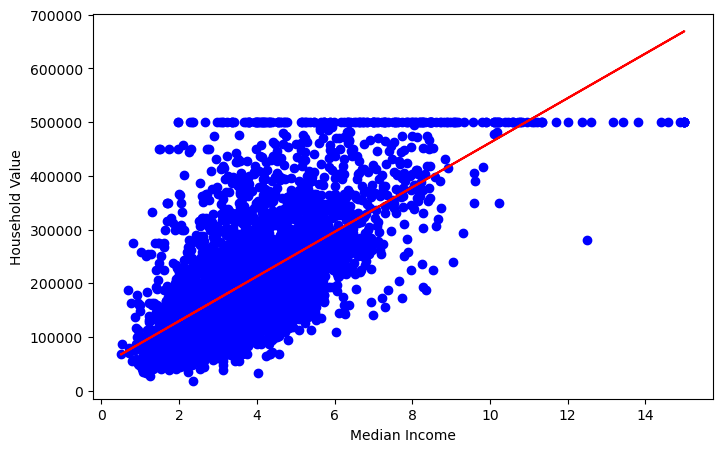

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(X_test,y_test,color="blue")
plt.plot(X_test,y_pred,color="red")
plt.xlabel("Median Income")
plt.ylabel("Household Value")
plt.show()

In [21]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print("MAE: ",mae)
print("MSE: ",mse)
print("RMSE: ",rmse)
print("R2-Score: ",r2)

MAE:  62606.40035097627
MSE:  6898954157.023464
RMSE:  83059.94315567201
R2-Score:  0.46801312690949415


### Multiple Linear Regression

In [22]:
df.columns

Index(['longitude', 'latitude', 'housingMedianAge', 'totalRooms',
       'totalBedrooms', 'population', 'households', 'medianIncome',
       'medianHouseValue'],
      dtype='object')

In [23]:
X = df.drop("medianHouseValue",axis=1)
y = df["medianHouseValue"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 1300
)

In [25]:
mlr = LinearRegression()
mlr.fit(X_train,y_train)

LinearRegression()

In [26]:
y_pred = mlr.predict(X_test)

In [27]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print("MAE: ",mae)
print("MSE: ",mse)
print("RMSE: ",rmse)
print("R2-Score: ",r2)

MAE:  50765.895309033294
MSE:  5048101585.28868
RMSE:  71049.99356290387
R2-Score:  0.610734653937806


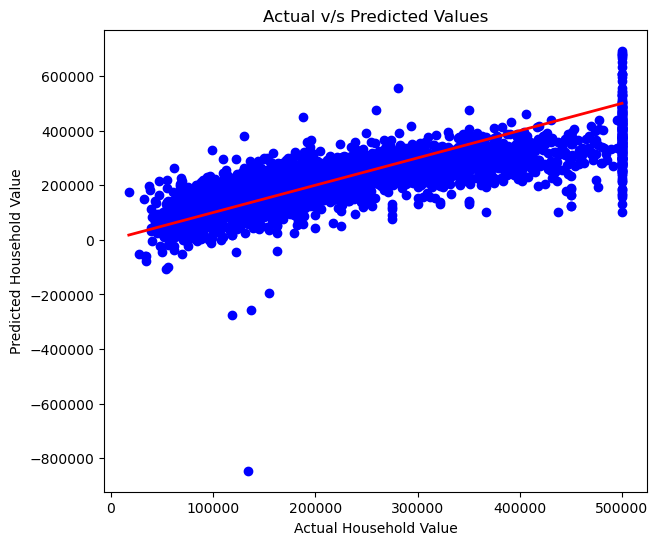

In [28]:
plt.figure(figsize=(7,6))
plt.scatter(y_test,y_pred,color="blue")

plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],
         color="red",linewidth=2)

plt.xlabel("Actual Household Value")
plt.ylabel("Predicted Household Value")
plt.title("Actual v/s Predicted Values")
plt.show()

## Hyperparameters Tunning

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
import numpy as np

In [30]:
lr = LinearRegression()

In [31]:
lr_params = {
    'fit_intercept' : [True,False],
    'positive' : [True,False]
}

In [32]:
grid_search = GridSearchCV(
    estimator = lr,
    param_grid = lr_params,
    cv = 5,
    scoring = 'r2',
    n_jobs = -1
)

In [33]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LinearRegression(), n_jobs=-1,
             param_grid={'fit_intercept': [True, False],
                         'positive': [True, False]},
             scoring='r2')

In [34]:
print("Best Parameters :")
print(grid_search.best_score_)

Best Parameters :
0.6419516687624947


In [35]:
best_model = grid_search.best_estimator_

In [36]:
LinearRegression(
    fit_intercept = True,
    positive = False
)

LinearRegression()

In [37]:
y_pred = best_model.predict(X_test)

In [38]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("MAE: ",mae)
print("MSE: ",mse)
print("RMSE: ",rmse)
print("R2-Score: ",r2)

MAE:  50765.895309033294
MSE:  5048101585.28868
RMSE:  71049.99356290387
R2-Score:  0.610734653937806


In [39]:
print(best_model)

LinearRegression()


In [40]:
results = grid_search.cv_results_

for mean_score, params in zip(results['mean_test_score'],results['params']):
    print(params, "R² = ", round(mean_score,4))

{'fit_intercept': True, 'positive': True} R² =  0.5264
{'fit_intercept': True, 'positive': False} R² =  0.642
{'fit_intercept': False, 'positive': True} R² =  0.5261
{'fit_intercept': False, 'positive': False} R² =  0.5843


## Ridge Regression

In [41]:
from sklearn.model_selection import GridSearchCV

In [42]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
print("Default Ridge R² : ", r2_score(y_test,ridge_pred))

Default Ridge R² :  0.6107358522376665


In [43]:
param_grid = {'alpha' : [0.001,0.01,0.1,1,10,100]}

In [44]:
grid_ridge = GridSearchCV(estimator=Ridge(),param_grid = param_grid,scoring = 'r2',cv = 5)

In [45]:
grid_ridge.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [46]:
print("Best Alpha: ", grid_ridge.best_params_)

Best Alpha:  {'alpha': 1}


In [47]:
print(grid_ridge.best_score_)

0.641951714452709


In [48]:
best_ridge = grid_ridge.best_estimator_
ridge_pred = best_ridge.predict(X_test)

In [49]:
mae = mean_absolute_error(y_test,ridge_pred)
mse = mean_squared_error(y_test,ridge_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,ridge_pred)

print("MAE: ",mae)
print("MSE: ",mse)
print("RMSE: ",rmse)
print("R2-Score: ",r2)

MAE:  50765.72963318182
MSE:  5048086045.40185
RMSE:  71049.8842040003
R2-Score:  0.6107358522376665


## Lasso Regression

In [50]:
from sklearn.linear_model import Lasso

param_grid = {
    'alpha':[0.001,0.01,0.1,1,10]}

In [51]:
grid_lasso = GridSearchCV(
    Lasso(max_iter = 5000),
    param_grid,cv = 5,
    scoring = 'r2'
)
grid_lasso.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Lasso(max_iter=5000),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10]}, scoring='r2')

In [53]:
print(grid_lasso.best_params_)

{'alpha': 10}


In [54]:
lasso_pred = grid_lasso.predict(X_test)
print(r2_score(y_test,lasso_pred))

0.6107387331558797
